# Versioned Resource Corpus for Agent Cache Testing

This notebook is a runnable, cell-split version of `data.py`, the script that builds the
**Versioned Resource Corpus for Agent Cache Testing** artifact.

The corpus is a versioned-resource **tool-call log** for offline evaluation of agent-side
caching policies. It is built entirely from real seed content:

- **`document`** resources: distinct Wikipedia passages (SQuAD `context` field, 200-400 words each).
- **`search_snippet`** resources: Quora Question Pairs duplicate-question groups, where the
  near-duplicate query used for search-then-refine repetition is QQP's own genuine
  `is_duplicate=1` label (not a hand-written or code-generated paraphrase).
- **`computed_value`** resources: real Our World in Data indicator series (population,
  coal-energy TWh, and COVID daily new_cases per country), remapped onto a simulated timeline.

Every resource carries an explicit `version_schedule` (list of
`{version_id, content_hash, valid_from_tick, valid_until_tick}`), so downstream experiment code
can replay the call stream in timestamp order against any cache policy (LRU, TTL, AIMD, etc.)
and score redundant-call reduction and stale-serve rate purely from this file.

This demo runs the **same build pipeline** as `data.py`, at a small scale, on a curated subset
of the real source data (`mini_demo_data.json`).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru is not pre-installed on Colab
_pip('loguru==0.7.3')

# numpy, matplotlib are pre-installed on Colab; install locally only, to match Colab's env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import hashlib
import json
import random
import sys

from loguru import logger

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

# extra imports for the demo (not in the original data.py)
import matplotlib.pyplot as plt


## Load the data

`mini_demo_data.json` is a curated subset of the real source data the original `data.py` pulls
from: SQuAD passages, QQP duplicate-question pairs, and OWID population/energy/covid tables.
It's loaded from GitHub with a local-file fallback so this notebook works both standalone and
in the pipeline's own workspace.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-a08cec-does-tcp-style-reactive-caching-actually/main/round-1/dataset-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")


In [4]:
data = load_data()
print({k: len(v) for k, v in data.items()})


{'squad_docs': 30, 'qqp_pairs': 20, 'population': 32, 'energy': 30, 'covid': 50}


## Config

Same tunable parameters as the top of `data.py`, scaled down to the absolute minimum that still
produces a meaningful corpus (a handful of documents/snippets/computed-values and a couple of
episodes). The original full-scale values are shown commented out.

In [5]:
RNG = random.Random(20260809)

SIM_DAYS = 30  # simulated timeline length (ticks = days)

# --- demo-scale (minimum viable) ---
N_DOCS = 8            # original: 180
N_SNIPPET_GROUPS = 6  # original: 120
N_POP_COUNTRIES = 4   # original: 25 (population resources)
N_ENERGY_COUNTRIES = 3  # original: 20 (energy resources)
N_EPISODES = 3        # original: 30

GAP_CHOICES = [1, 3, 7, 14]  # simulated-day gaps for read-then-reread
CHECKED_SUBSAMPLE_RATE = 0.15  # fraction of calls with a spot-check label


## Real-content loaders

These mirror `data.py`'s `load_squad_docs`, `load_qqp_snippet_groups`, and `load_owid_series`
functions, but read from the `mini_demo_data.json` fields already loaded into `data` instead of
re-downloading full HuggingFace/OWID source tables from disk.

In [6]:
def content_hash(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8")).hexdigest()[:16]


def load_squad_docs(n: int) -> list[dict]:
    """~n distinct real Wikipedia passages (SQuAD 'context' field) -> static document resources."""
    rows = data["squad_docs"]
    logger.info(f"Loading SQuAD contexts from mini_demo_data.json (squad_docs)")
    seen: dict[str, dict] = {}
    for row in rows:
        ctx = row["context"]
        if ctx not in seen and 200 <= len(ctx.split()) <= 400:
            seen[ctx] = {"title": row["title"], "context": ctx}
        if len(seen) >= n * 3:
            break
    contexts = list(seen.values())
    RNG.shuffle(contexts)
    contexts = contexts[:n]
    logger.info(f"Selected {len(contexts)} distinct SQuAD passages")
    return contexts


def load_qqp_snippet_groups(n: int) -> list[dict]:
    """Real Quora duplicate-question groups -> snippet resources with genuine near-duplicate
    query variants (the dataset's own is_duplicate=1 pairs), content = canonical question text."""
    dup_pairs = [r for r in data["qqp_pairs"] if r.get("is_duplicate") == 1]
    logger.info(f"Loading QQP duplicate pairs from mini_demo_data.json (qqp_pairs)")
    RNG.shuffle(dup_pairs)
    groups = []
    seen_q1 = set()
    for r in dup_pairs:
        q1, q2 = r["question1"].strip(), r["question2"].strip()
        if not q1 or not q2 or q1 in seen_q1:
            continue
        seen_q1.add(q1)
        groups.append({"canonical_query": q1, "content": q1, "near_dup_queries": [q2]})
        if len(groups) >= n:
            break
    logger.info(f"Selected {len(groups)} QQP near-duplicate query groups")
    return groups


def load_owid_series() -> dict:
    """Real dated indicator sequences from OWID: population (slow/static-ish),
    energy_mix share (periodic, annual), covid new_cases (bursty, daily)."""
    logger.info("Loading OWID indicator series from mini_demo_data.json")

    countries_pop = {}
    for row in data["population"]:
        if row.get("country") and 2000 <= row.get("year", 0) <= 2023 and row.get("population"):
            countries_pop.setdefault(row["country"], []).append((row["year"], row["population"]))

    countries_energy = {}
    for row in data["energy"]:
        c = row.get("country")
        y = row.get("year")
        v = row.get("coal__twh")
        if c and y and v is not None and 2000 <= y <= 2023:
            countries_energy.setdefault(c, []).append((y, round(v, 2)))

    bursty_countries = ["United States", "Germany", "Brazil", "India", "Japan"]
    countries_covid: dict[str, list] = {c: [] for c in bursty_countries}
    for rec in data["covid"]:
        c = rec.get("location")
        if c in countries_covid:
            nc = rec.get("new_cases")
            date = rec.get("date")
            if nc is not None and date and "2021-03" <= date[:7] <= "2021-05":
                countries_covid[c].append((date[:10], int(nc)))

    logger.info(
        f"OWID series loaded: {len(countries_pop)} pop countries, "
        f"{len(countries_energy)} energy countries, "
        f"{sum(len(v) for v in countries_covid.values())} covid daily points"
    )
    return {"population": countries_pop, "energy": countries_energy, "covid": countries_covid}


## Resource construction

Each real-content item becomes a `resource` dict with a `version_schedule` — the ground-truth
record of which `version_id` is valid at which simulated tick. SQuAD/QQP content only exists at
one real snapshot, so those resources are marked `static`/`real_single_snapshot`. OWID series
drive genuinely `periodic` (population, energy) or `bursty` (covid) schedules from their real
cadence.

In [7]:
def day_to_tick(day: int) -> int:
    return max(0, min(SIM_DAYS - 1, day))


def build_document_resources(docs: list[dict]) -> list[dict]:
    """SQuAD gives a single real snapshot per passage -> mark STATIC (no fabricated edits),
    per plan Step 1 fallback rule."""
    resources = []
    for i, d in enumerate(docs):
        rid = f"doc_{i:04d}"
        vid = f"{rid}_v0"
        resources.append({
            "resource_id": rid,
            "resource_class": "document",
            "volatility_regime": "static",
            "timing_provenance": "real_single_snapshot",
            "content_by_version": {vid: d["context"]},
            "version_schedule": [
                {"version_id": vid, "content_hash": content_hash(d["context"]),
                 "valid_from_tick": 0, "valid_until_tick": SIM_DAYS - 1}
            ],
            "extra": {"title": d["title"]},
        })
    return resources


def build_snippet_resources_qqp(groups: list[dict]) -> list[dict]:
    """QQP gives one real content string + genuine dataset-provided near-duplicate query
    variant per group -> STATIC content (QQP has no second dated snapshot), but the
    near-duplicate QUERY pattern itself is fully real (search-then-refine, Step 2)."""
    resources = []
    for i, d in enumerate(groups):
        rid = f"snip_qqp_{i:04d}"
        vid = f"{rid}_v0"
        resources.append({
            "resource_id": rid,
            "resource_class": "search_snippet",
            "volatility_regime": "static",
            "timing_provenance": "real_single_snapshot",
            "content_by_version": {vid: d["content"]},
            "version_schedule": [
                {"version_id": vid, "content_hash": content_hash(d["content"]),
                 "valid_from_tick": 0, "valid_until_tick": SIM_DAYS - 1}
            ],
            "extra": {"canonical_query": d["canonical_query"], "near_dup_queries": d["near_dup_queries"]},
        })
    return resources


def build_computed_resources(series: dict) -> list[dict]:
    """Real OWID indicator sequences drive the version_schedule directly:
    population (slow -> periodic, few real updates in-window), energy coal share (periodic,
    annual real cadence), covid new_cases (bursty, real daily cadence w/ irregular jumps)."""
    resources = []
    idx = 0

    # PERIODIC (slow, real annual cadence): population, pick last N_YEARS years present,
    # map real years onto the 30-day simulated window in order.
    pop_countries = list(series["population"].items())[:N_POP_COUNTRIES]
    for country, yearly in pop_countries:
        yearly = sorted(yearly)[-6:]  # last up to 6 real annual values
        if len(yearly) < 2:
            continue
        rid = f"comp_pop_{idx:04d}"
        idx += 1
        n = len(yearly)
        schedule = []
        content_by_version = {}
        for j, (year, val) in enumerate(yearly):
            vid = f"{rid}_v{j}"
            tick_from = day_to_tick(round(j * SIM_DAYS / n))
            tick_to = day_to_tick(round((j + 1) * SIM_DAYS / n) - 1) if j < n - 1 else SIM_DAYS - 1
            content_by_version[vid] = {"country": country, "year": year, "population": val}
            schedule.append({"version_id": vid, "content_hash": content_hash(f"{val}"),
                              "valid_from_tick": tick_from, "valid_until_tick": tick_to})
        resources.append({
            "resource_id": rid, "resource_class": "computed_value",
            "volatility_regime": "periodic", "timing_provenance": "real_owid_cadence_remapped_to_window",
            "content_by_version": content_by_version, "version_schedule": schedule,
            "extra": {"indicator": "population", "country": country},
        })

    # PERIODIC (annual, real cadence): energy coal TWh share, same remap approach
    energy_countries = list(series["energy"].items())[:N_ENERGY_COUNTRIES]
    for country, yearly in energy_countries:
        yearly = sorted(yearly)[-6:]
        if len(yearly) < 2:
            continue
        rid = f"comp_energy_{idx:04d}"
        idx += 1
        n = len(yearly)
        schedule = []
        content_by_version = {}
        for j, (year, val) in enumerate(yearly):
            vid = f"{rid}_v{j}"
            tick_from = day_to_tick(round(j * SIM_DAYS / n))
            tick_to = day_to_tick(round((j + 1) * SIM_DAYS / n) - 1) if j < n - 1 else SIM_DAYS - 1
            content_by_version[vid] = {"country": country, "year": year, "coal_twh": val}
            schedule.append({"version_id": vid, "content_hash": content_hash(f"{val}"),
                              "valid_from_tick": tick_from, "valid_until_tick": tick_to})
        resources.append({
            "resource_id": rid, "resource_class": "computed_value",
            "volatility_regime": "periodic", "timing_provenance": "real_owid_cadence_remapped_to_window",
            "content_by_version": content_by_version, "version_schedule": schedule,
            "extra": {"indicator": "coal_energy_twh", "country": country},
        })

    # BURSTY (real daily cadence, genuinely irregular jumps): covid new_cases, mapped
    # 1 real day -> 1 simulated tick directly (fully real timing, no injection needed).
    for country, daily in series["covid"].items():
        daily = sorted(daily)[:SIM_DAYS]
        if len(daily) < 5:
            continue
        rid = f"comp_covid_{idx:04d}"
        idx += 1
        schedule = []
        content_by_version = {}
        for j, (date, val) in enumerate(daily):
            vid = f"{rid}_v{j}"
            tick = day_to_tick(j)
            tick_to = day_to_tick(j + 1) - 1 if j < len(daily) - 1 else SIM_DAYS - 1
            if tick_to < tick:
                tick_to = tick
            content_by_version[vid] = {"country": country, "date": date, "new_cases": val}
            schedule.append({"version_id": vid, "content_hash": content_hash(f"{val}"),
                              "valid_from_tick": tick, "valid_until_tick": tick_to})
        resources.append({
            "resource_id": rid, "resource_class": "computed_value",
            "volatility_regime": "bursty", "timing_provenance": "real_owid_daily_cadence",
            "content_by_version": content_by_version, "version_schedule": schedule,
            "extra": {"indicator": "covid_new_cases", "country": country},
        })

    logger.info(f"Built {len(resources)} computed-value resources")
    return resources


## Episode (tool-call log) generation

Each simulated episode replays three access templates against the resource pool:

- **read-then-reread** — pick some documents, revisit each several times with realistic gaps.
- **search-then-refine** — pick some snippet groups, issue several near-duplicate queries each.
- **compute-then-reuse** — pick some computed values, reuse each several times.

Every call is stamped with the `ground_truth_version_id` valid at that call's simulated tick,
via `version_at_tick`.

In [8]:
def version_at_tick(resource: dict, tick: int) -> str:
    for v in resource["version_schedule"]:
        if v["valid_from_tick"] <= tick <= v["valid_until_tick"]:
            return v["version_id"]
    return resource["version_schedule"][-1]["version_id"]


def gen_episodes(docs: list[dict], snippets: list[dict], computed: list[dict], snippet_kind: str) -> list[dict]:
    episodes = []
    for ep_i in range(N_EPISODES):
        episode_id = f"ep_{ep_i:03d}"
        calls = []
        call_idx = 0
        start_tick = RNG.randint(0, 10)

        # Template A: read-then-reread — pick 10-16 docs, revisit each 4-10 times with gaps
        n_docs_this_ep = RNG.randint(10, 16)
        for doc in RNG.sample(docs, min(n_docs_this_ep, len(docs))):
            n_revisits = RNG.randint(4, 10)
            tick = start_tick
            for _ in range(n_revisits):
                calls.append((tick, "read_file", f"read_file(doc_id={doc['resource_id']})", doc))
                tick = day_to_tick(tick + RNG.choice(GAP_CHOICES))

        # Template B: search-then-refine — 8-14 snippet groups, 3-6 near-duplicate query calls each
        n_snip_this_ep = RNG.randint(8, 14)
        for snip in RNG.sample(snippets, min(n_snip_this_ep, len(snippets))):
            n_refines = RNG.randint(3, 6)
            tick = RNG.randint(0, SIM_DAYS - 1)
            near_dups = snip["extra"].get("near_dup_queries", [])
            for k in range(n_refines):
                q = snip["extra"]["canonical_query"] if k == 0 or not near_dups else RNG.choice(near_dups)
                calls.append((tick, "web_search", f"web_search(query={q!r})", snip))
                tick = day_to_tick(tick + RNG.choice([0, 0, 1]))

        # Template C: compute-then-reuse — 6-10 computed values, reused 3-6 times each
        n_comp_this_ep = RNG.randint(6, 10)
        for comp in RNG.sample(computed, min(n_comp_this_ep, len(computed))):
            n_reuse = RNG.randint(3, 6)
            tick = RNG.randint(0, SIM_DAYS - 1)
            inputs_sig = f"{comp['extra'].get('indicator')}_{comp['extra'].get('country')}"
            for _ in range(n_reuse):
                calls.append((tick, "compute", f"compute(inputs={inputs_sig})", comp))
                tick = day_to_tick(tick + RNG.choice(GAP_CHOICES))

        calls.sort(key=lambda c: c[0])
        for tick, fn, sig, res in calls:
            gt_vid = version_at_tick(res, tick)
            calls_obj = {
                "episode_id": episode_id, "call_index": call_idx, "timestamp_tick": tick,
                "call_site_signature": sig, "resource_id": res["resource_id"],
                "ground_truth_version_id": gt_vid, "resource": res,
            }
            episodes.append(calls_obj)
            call_idx += 1
    return episodes


def rows_to_examples(call_rows: list[dict]) -> list[dict]:
    examples = []
    for row in call_rows:
        res = row["resource"]
        content_now = res["content_by_version"][row["ground_truth_version_id"]]
        content_str = content_now if isinstance(content_now, str) else json.dumps(content_now)
        checked = RNG.random() < CHECKED_SUBSAMPLE_RATE
        input_obj = {
            "episode_id": row["episode_id"],
            "call_index": row["call_index"],
            "timestamp_tick": row["timestamp_tick"],
            "call_site_signature": row["call_site_signature"],
            "resource_id": row["resource_id"],
        }
        ex = {
            "input": json.dumps(input_obj, ensure_ascii=False),
            "output": row["ground_truth_version_id"],
            "metadata_resource_class": res["resource_class"],
            "metadata_volatility_regime": res["volatility_regime"],
            "metadata_timing_provenance": res["timing_provenance"],
            "metadata_content_now": content_str[:600],
            "metadata_version_schedule": json.dumps(res["version_schedule"], ensure_ascii=False),
            "metadata_checked": checked,
            "metadata_sim_days": SIM_DAYS,
        }
        examples.append(ex)
    return examples


## Run the pipeline

This mirrors `data.py`'s `main()`: load real content, build resources, generate episodes,
flatten to per-tool-call examples in the `exp_sel_data_out.json` schema.

In [9]:
logger.info("=== Building chosen dataset: qqp snippets (real near-duplicate queries) ===")
docs = load_squad_docs(N_DOCS)
series = load_owid_series()

doc_resources = build_document_resources(docs)
computed_resources = build_computed_resources(series)

qqp_groups = load_qqp_snippet_groups(N_SNIPPET_GROUPS)
snip = build_snippet_resources_qqp(qqp_groups)
episodes = gen_episodes(doc_resources, snip, computed_resources, "qqp")
examples = rows_to_examples(episodes)
logger.info(f"cache_corpus: {len(examples)} call-log examples, "
            f"{len(doc_resources)} docs + {len(snip)} snippets + {len(computed_resources)} computed resources")

output = {
    "metadata": {
        "description": "Versioned Resource Corpus for Agent Cache Testing: real-content "
                        "resources (documents/search-snippets/computed-values) with ground-truth "
                        "version schedules over a 30-day simulated timeline, flattened to "
                        "per-tool-call log rows across episodes. Search-snippet near-duplicate "
                        "queries are Quora Question Pairs' own genuine is_duplicate=1 pairs.",
        "sim_days": SIM_DAYS,
        "n_episodes": N_EPISODES,
    },
    "datasets": [
        {"dataset": "cache_corpus", "examples": examples},
    ],
}

out_path = "code_demo_output.json"
with open(out_path, "w") as f:
    json.dump(output, f, ensure_ascii=False)
import os
logger.info(f"Saved {out_path} ({os.path.getsize(out_path) / 1e3:.1f} KB)")


06:16:59|INFO   |=== Building chosen dataset: qqp snippets (real near-duplicate queries) ===


06:16:59|INFO   |Loading SQuAD contexts from mini_demo_data.json (squad_docs)


06:16:59|INFO   |Selected 8 distinct SQuAD passages


06:16:59|INFO   |Loading OWID indicator series from mini_demo_data.json


06:16:59|INFO   |OWID series loaded: 6 pop countries, 5 energy countries, 50 covid daily points


06:16:59|INFO   |Built 12 computed-value resources


06:16:59|INFO   |Loading QQP duplicate pairs from mini_demo_data.json (qqp_pairs)


06:16:59|INFO   |Selected 6 QQP near-duplicate query groups


06:16:59|INFO   |cache_corpus: 370 call-log examples, 8 docs + 6 snippets + 12 computed resources


06:16:59|INFO   |Saved code_demo_output.json (436.8 KB)


## Results

A quick look at the generated corpus: composition by resource class / volatility regime, and
call-site (`resource_id`) recurrence — the repetition that gives cache policies (LRU/TTL/AIMD)
room to adapt.

Total call-log examples: 370

By resource_class:
  computed_value    109
  document          181
  search_snippet     80

By volatility_regime:
  periodic           55
  static            261
  bursty             54

Median resource_id recurrence (calls per resource): 14


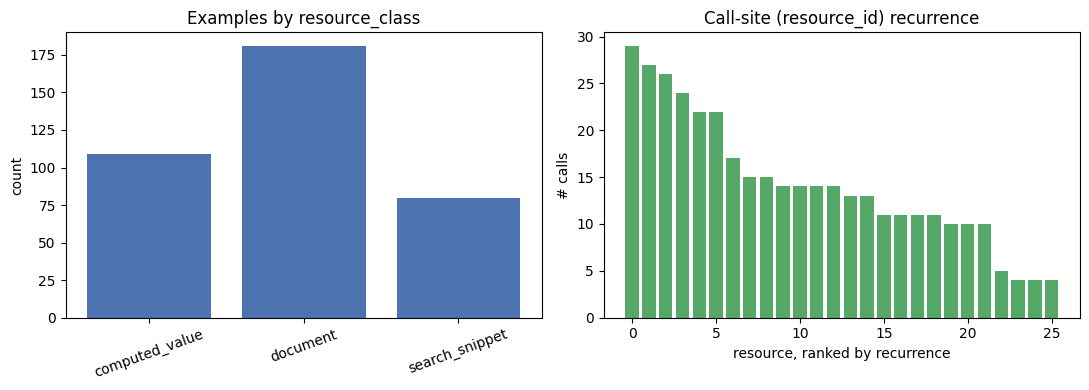

In [10]:
from collections import Counter

class_counts = Counter(ex["metadata_resource_class"] for ex in examples)
regime_counts = Counter(ex["metadata_volatility_regime"] for ex in examples)
resource_id_counts = Counter(json.loads(ex["input"])["resource_id"] for ex in examples)

print(f"Total call-log examples: {len(examples)}")
print(f"\nBy resource_class:")
for k, v in class_counts.items():
    print(f"  {k:16s} {v:4d}")
print(f"\nBy volatility_regime:")
for k, v in regime_counts.items():
    print(f"  {k:16s} {v:4d}")
print(f"\nMedian resource_id recurrence (calls per resource): "
      f"{sorted(resource_id_counts.values())[len(resource_id_counts)//2]}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(class_counts.keys(), class_counts.values(), color="#4C72B0")
axes[0].set_title("Examples by resource_class")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=20)

recurrence = sorted(resource_id_counts.values(), reverse=True)
axes[1].bar(range(len(recurrence)), recurrence, color="#55A868")
axes[1].set_title("Call-site (resource_id) recurrence")
axes[1].set_xlabel("resource, ranked by recurrence")
axes[1].set_ylabel("# calls")

plt.tight_layout()
plt.show()
